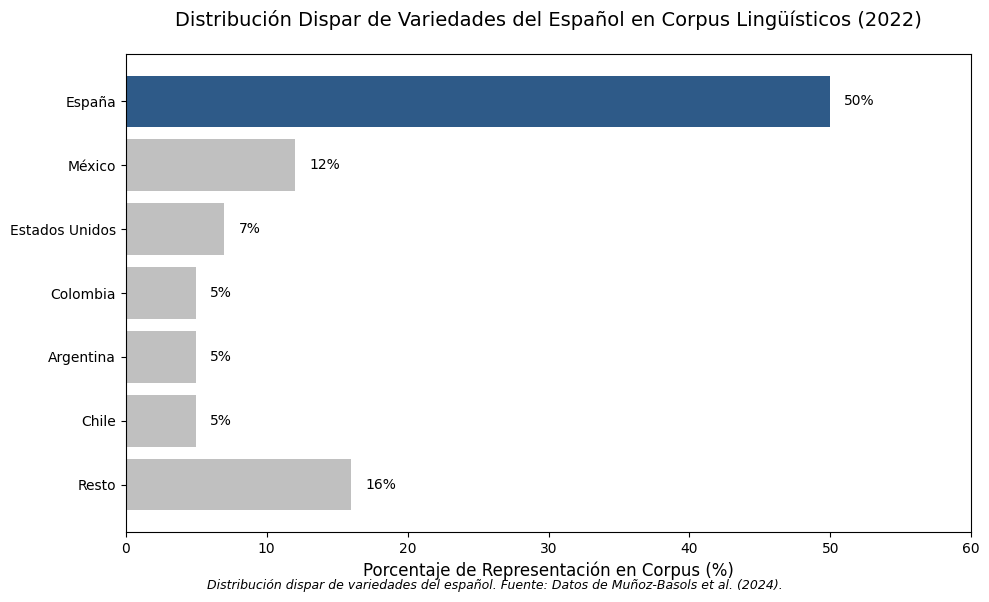

In [ ]:
import matplotlib.pyplot as plt

# datos extraídos de muñoz-basols et al. (2024) y melero et al. (2022) [cite: 1306, 1309]
variedades = ['España', 'México', 'Estados Unidos', 'Colombia', 'Argentina', 'Chile', 'Resto']
porcentajes = [50, 12, 7, 5, 5, 5, 16] # resto calculado como remanente [cite: 1310]

# configuración de colores: azul académico para españa, gris neutro para el resto
colores = ['#2E5A88' if v == 'España' else '#C0C0C0' for v in variedades]

# crear gráfico
plt.figure(figsize=(10, 6))
barras = plt.barh(variedades, porcentajes, color=colores)

# estética académica limpia
plt.xlabel('Porcentaje de Representación en Corpus (%)', fontsize=12)
plt.title('Distribución Dispar de Variedades del Español en Corpus Lingüísticos (2022)', fontsize=14, pad=20)
plt.gca().invert_yaxis()  # ordena de mayor a menor visualmente
plt.xlim(0, 60) # espacio para las etiquetas

# añadir etiquetas de valor numérico
for barra in barras:
    width = barra.get_width()
    plt.text(width + 1, barra.get_y() + barra.get_height()/2, f'{width}%',
            va='center', fontsize=10)

# pie de figura integrado (opcional, mejor ponerlo en el documento de texto)
plt.figtext(0.5, 0.01,
            "Distribución dispar de variedades del español. Fuente: Datos de Muñoz-Basols et al. (2024).",
            ha="center", fontsize=9, style='italic')

plt.tight_layout()
# guardar en alta calidad
plt.savefig('grafico_desproporcion_espanol.png', bbox_inches='tight', dpi=300)
plt.show()

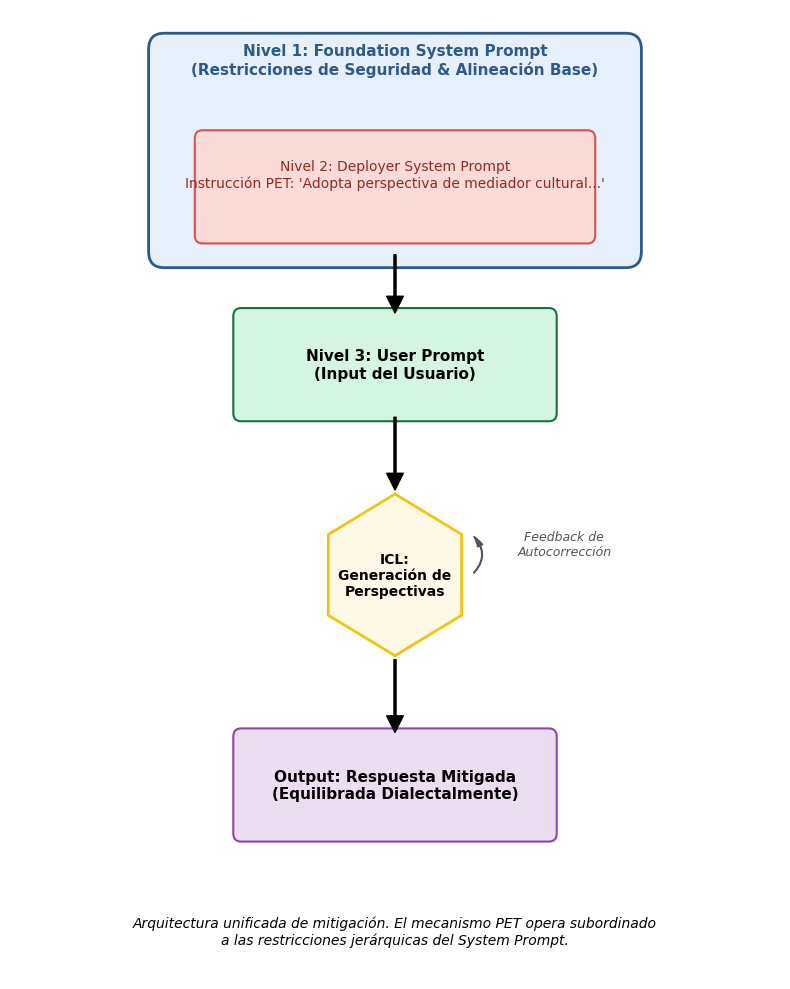

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# configuración de la figura
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')  # ocultar ejes para que parezca un diagrama

# --- CORRECCIÓN AQUÍ ---
# usamos FancyBboxPatch en lugar de Rectangle para soportar bordes redondeados (boxstyle)
def draw_box(x, y, width, height, color, label, fontsize=10, alpha=1.0, ec='black'):
    rect = patches.FancyBboxPatch((x, y), width, height,
                                  boxstyle="round,pad=0.1",
                                  linewidth=1.5,
                                  edgecolor=ec,
                                  facecolor=color,
                                  alpha=alpha)
    ax.add_patch(rect)
    # texto centrado
    ax.text(x + width/2, y + height/2, label, ha='center', va='center',
            fontsize=fontsize, weight='bold' if fontsize>10 else 'normal')
    return rect

# --- NIVEL 1 & 2: SYSTEM PROMPTS (JERARQUÍA) ---
# caja contenedora grande (foundation system prompt)
ax.add_patch(patches.FancyBboxPatch((2, 9), 6, 2.5, boxstyle="round,pad=0.2", linewidth=2, edgecolor='#2E5A88', facecolor='#E6F0FA'))
ax.text(5, 11.2, "Nivel 1: Foundation System Prompt\n(Restricciones de Seguridad & Alineación Base)", ha='center', fontsize=11, weight='bold', color='#2E5A88')

# caja interna (deployer / pet instruction)
ax.add_patch(patches.FancyBboxPatch((2.5, 9.2), 5, 1.2, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='#D9534F', facecolor='#FADBD8'))
ax.text(5, 9.8, "Nivel 2: Deployer System Prompt\nInstrucción PET: 'Adopta perspectiva de mediador cultural...'", ha='center', fontsize=10, color='#922B21')

# --- FLECHA DE FLUJO 1 ---
ax.annotate('', xy=(5, 8.2), xytext=(5, 9.0), arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))

# --- NIVEL 3: USER PROMPT ---
draw_box(3, 7.0, 4, 1.2, '#D5F5E3', "Nivel 3: User Prompt\n(Input del Usuario)", fontsize=11, ec='#196F3D')

# --- FLECHA DE FLUJO 2 ---
ax.annotate('', xy=(5, 6.0), xytext=(5, 7.0), arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))

# --- PROCESO: GENERACIÓN DE PERSPECTIVAS (ICL) ---
# usamos un rombo o caja hexagonal para denotar "Proceso"
ax.add_patch(patches.RegularPolygon((5, 5.0), numVertices=6, radius=1.0, orientation=0, facecolor='#FEF9E7', edgecolor='#F1C40F', linewidth=2))
ax.text(5, 5.0, "ICL:\nGeneración de\nPerspectivas", ha='center', va='center', fontsize=10, weight='bold')

# --- DETALLE DE FEEDBACK (flecha curva) ---
# dibujamos una flecha curva que sale del proceso y vuelve para simular "Autocorrección"
style = "Simple, tail_width=0.5, head_width=4, head_length=8"
kw = dict(arrowstyle=style, color="#555555")
# flecha curva
curve = patches.FancyArrowPatch((6.0, 5.0), (6.0, 5.5), connectionstyle="arc3,rad=.5", **kw)
ax.add_patch(curve)
ax.text(7.2, 5.25, "Feedback de\nAutocorrección", ha='center', fontsize=9, style='italic', color='#555555')

# --- FLECHA DE FLUJO 3 ---
ax.annotate('', xy=(5, 3.0), xytext=(5, 4.0), arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))

# --- OUTPUT FINAL ---
draw_box(3, 1.8, 4, 1.2, '#EBDEF0', "Output: Respuesta Mitigada\n(Equilibrada Dialectalmente)", fontsize=11, ec='#8E44AD')

# --- PIE DE FIGURA ---
plt.figtext(0.5, 0.05,
            "Arquitectura unificada de mitigación. El mecanismo PET opera subordinado\na las restricciones jerárquicas del System Prompt.",
            ha="center", fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('diagrama_flujo_mitigacion.png', bbox_inches='tight', dpi=300)
plt.show()

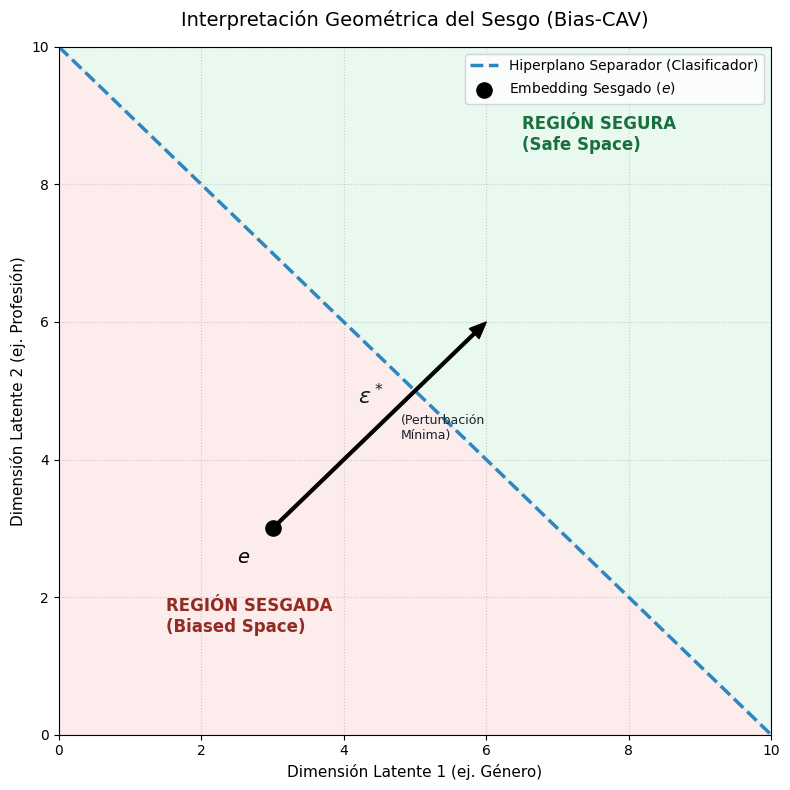

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# configuración de la figura
fig, ax = plt.subplots(figsize=(8, 8))

# 1. definir el hiperplano separador (línea diagonal)
# ecuación: y = -x + 10 (ejemplo conceptual)
x = np.linspace(0, 10, 100)
y_hyperplane = -1 * x + 10

# 2. colorear las regiones (fill_between)
# región segura (verde) - encima de la línea
ax.fill_between(x, y_hyperplane, 10, color='#D5F5E3', alpha=0.5)
# región sesgada (roja) - debajo de la línea
ax.fill_between(x, 0, y_hyperplane, color='#FADBD8', alpha=0.5)

# 3. dibujar el hiperplano
ax.plot(x, y_hyperplane, color='#2E86C1', linewidth=2.5, linestyle='--', label='Hiperplano Separador (Clasificador)')

# 4. definir puntos clave
# embedding sesgado (e) en la zona roja
e_x, e_y = 3, 3
# punto objetivo (target) en la zona verde (cruzando la frontera)
# nos movemos en la dirección normal al plano (1, 1)
target_x, target_y = 6, 6

# 5. dibujar el punto sesgado
ax.scatter(e_x, e_y, color='black', s=120, zorder=5, label='Embedding Sesgado ($e$)')
ax.text(e_x - 0.5, e_y - 0.5, '$e$', fontsize=14, weight='bold')

# 6. dibujar el vector de perturbación (flecha epsilon)
ax.annotate('', xy=(target_x, target_y), xytext=(e_x, e_y),
            arrowprops=dict(facecolor='black', shrink=0, width=2, headwidth=10))
# etiqueta del vector
ax.text(4.2, 4.8, r'$\epsilon^*$', fontsize=16, weight='bold', color='#17202A')
ax.text(4.8, 4.3, '(Perturbación\nMínima)', fontsize=9, color='#17202A')

# 7. etiquetas de regiones
ax.text(1.5, 1.5, 'REGIÓN SESGADA\n(Biased Space)', fontsize=12, color='#922B21', weight='bold')
ax.text(6.5, 8.5, 'REGIÓN SEGURA\n(Safe Space)', fontsize=12, color='#196F3D', weight='bold')

# estética académica
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xlabel('Dimensión Latente 1 (ej. Género)', fontsize=11)
ax.set_ylabel('Dimensión Latente 2 (ej. Profesión)', fontsize=11)
ax.set_title('Interpretación Geométrica del Sesgo (Bias-CAV)', fontsize=14, pad=15)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)



plt.tight_layout()
# guardar
plt.savefig('grafico_geometrico_bias_cav.png', bbox_inches='tight', dpi=300)
plt.show()

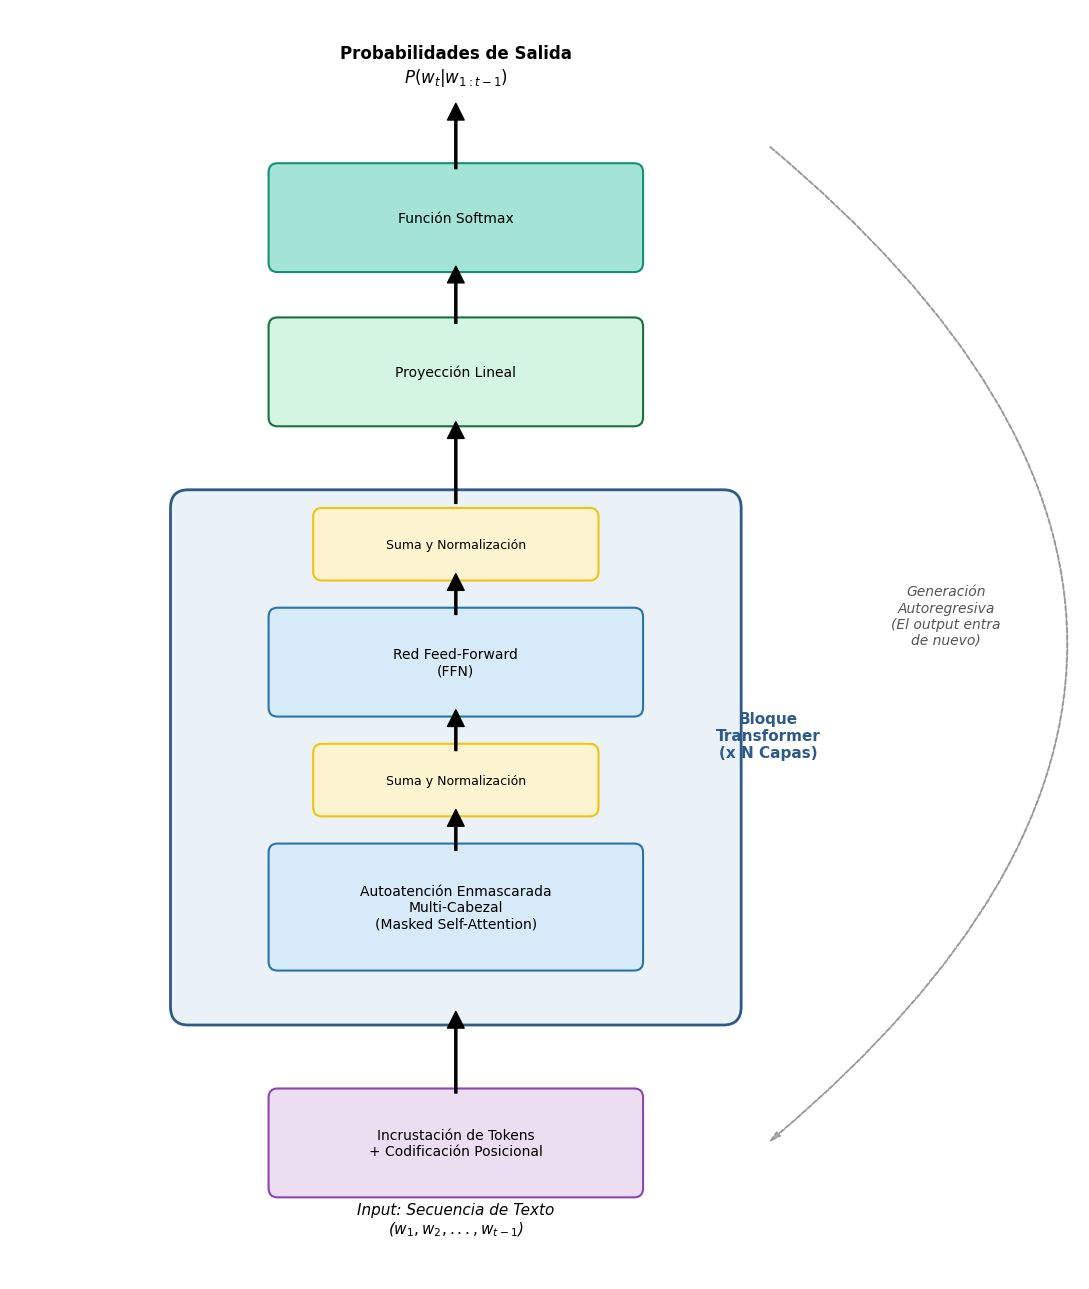

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuración de la figura
# Aumentamos el ancho (figsize) y el límite X para dar espacio a la flecha externa
fig, ax = plt.subplots(figsize=(11, 13))
ax.set_xlim(0, 12)
ax.set_ylim(0, 14)
ax.axis('off')

# Función auxiliar para dibujar cajas
def draw_box(x, y, width, height, color, label, fontsize=10, ec='black'):
    rect = patches.FancyBboxPatch((x, y), width, height,
                                  boxstyle="round,pad=0.1",
                                  linewidth=1.5,
                                  edgecolor=ec,
                                  facecolor=color)
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, label, ha='center', va='center',
            fontsize=fontsize, weight='bold' if fontsize > 10 else 'normal')

# Función para dibujar flechas rectas
def draw_arrow(x_start, y_start, y_end):
    ax.annotate('', xy=(x_start, y_end), xytext=(x_start, y_start),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))

# --- 1. INPUTS ---
ax.text(5, 0.5, "Input: Secuencia de Texto\n($w_1, w_2, ..., w_{t-1}$)", ha='center', fontsize=11, style='italic')

# TRADUCCIÓN: Embeddings -> Incrustaciones
draw_box(3, 1.0, 4, 1.0, '#EBDEF0', "Incrustación de Tokens\n+ Codificación Posicional", ec='#8E44AD')

draw_arrow(5, 2.0, 3.0)

# --- 2. TRANSFORMER BLOCK (N Layers) ---
# Caja contenedora del bloque repetitivo
# NOTA: Esta caja va de x=2 hasta x=8 (2+6). La flecha debe estar en x > 8.
ax.add_patch(patches.FancyBboxPatch((2, 3.0), 6, 5.5, boxstyle="round,pad=0.2", linewidth=2, edgecolor='#2E5A88', facecolor='#EAF2F8'))
ax.text(8.5, 5.75, "Bloque\nTransformer\n(x N Capas)", ha='center', fontsize=11, weight='bold', color='#2E5A88')

# Componentes internos del bloque (TRADUCIDOS)
draw_box(3, 3.5, 4, 1.2, '#D6EAF8', "Autoatención Enmascarada\nMulti-Cabezal\n(Masked Self-Attention)", ec='#2874A6')
draw_arrow(5, 4.7, 5.2)

draw_box(3.5, 5.2, 3, 0.6, '#FCF3CF', "Suma y Normalización", fontsize=9, ec='#F1C40F')
draw_arrow(5, 5.8, 6.3)

draw_box(3, 6.3, 4, 1.0, '#D6EAF8', "Red Feed-Forward\n(FFN)", ec='#2874A6')
draw_arrow(5, 7.3, 7.8)

draw_box(3.5, 7.8, 3, 0.6, '#FCF3CF', "Suma y Normalización", fontsize=9, ec='#F1C40F')

# Salida del bloque
draw_arrow(5, 8.5, 9.5)

# --- 3. OUTPUT HEAD ---
# TRADUCCIÓN: Linear -> Proyección Lineal
draw_box(3, 9.5, 4, 1.0, '#D5F5E3', "Proyección Lineal", ec='#196F3D')
draw_arrow(5, 10.5, 11.2)

# TRADUCCIÓN: Softmax
draw_box(3, 11.2, 4, 1.0, '#A3E4D7', "Función Softmax", ec='#148F77')

# --- 4. PREDICTION ---
draw_arrow(5, 12.2, 13.0)
ax.text(5, 13.2, "Probabilidades de Salida\n$P(w_t | w_{1:t-1})$", ha='center', fontsize=12, weight='bold')

# --- DETALLES Y FLECHA CURVA CORREGIDA ---
# CORRECCIÓN:
# El bloque grande termina en X=8.0.
# Movemos la flecha para que empiece y termine en X=8.5 (fuera del bloque).
# Usamos una curvatura negativa (rad=-0.5) para que el arco se vaya hacia la derecha (hacia X=10 o más).

style = "Simple, tail_width=0.5, head_width=4, head_length=8"
kw = dict(arrowstyle=style, color="#777777")

# Coordenadas: Salimos de arriba (8.5, 12.0) y llegamos abajo (8.5, 1.5)
# rad=-0.6 fuerza la curva hacia la derecha (alejándose del centro)
curve = patches.FancyArrowPatch((8.5, 12.5), (8.5, 1.5),
                                connectionstyle="arc3,rad=-0.6",
                                **kw, alpha=0.6, linestyle='--')
ax.add_patch(curve)

# Texto de la flecha movido a X=10.5 para no chocar con la curva
ax.text(10.5, 7.0, "Generación\nAutoregresiva\n(El output entra\nde nuevo)", ha='center', fontsize=10, style='italic', color='#555555')




plt.tight_layout()
plt.savefig('diagrama_transformer_espanol_corregido.png', bbox_inches='tight', dpi=300)
plt.show()

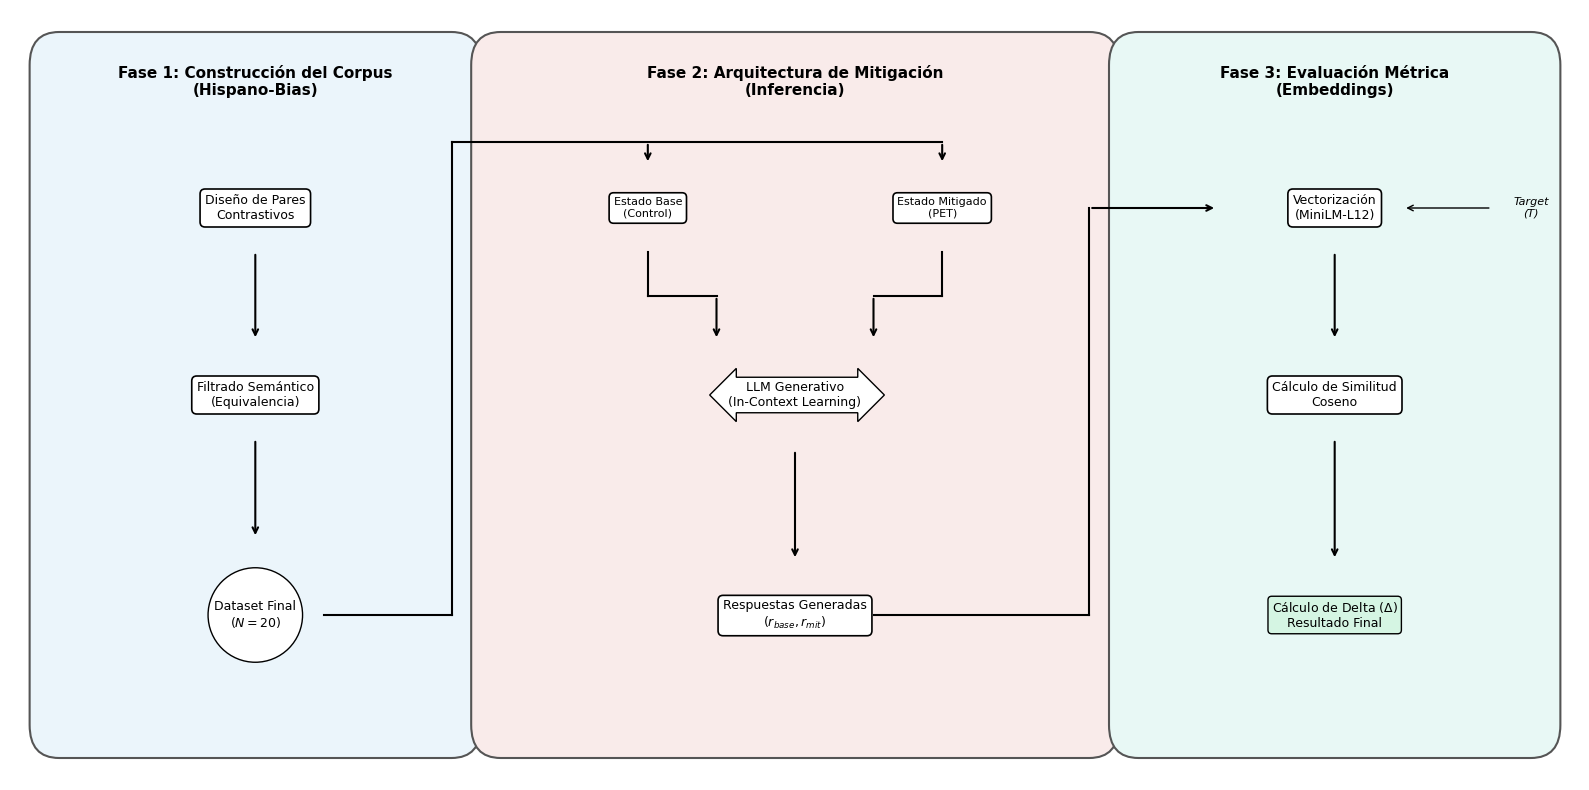

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_workflow_final_safe():
    # Configuración del lienzo
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 7)
    ax.axis('off')

    # Estilos
    container_style = dict(boxstyle="round,pad=0.3", lw=1.5, ec="#555555")
    box_style = dict(boxstyle="round,pad=0.4", ec="black", fc="white", lw=1.2)

    # --- COORDENADAS MAESTRAS ---
    x_p1 = 2.5
    x_p2_L = 6.5  # Control
    x_p2_R = 9.5  # Mitigado
    x_p2_Mid = 8.0 # LLM
    x_p3 = 13.5

    # --- FONDOS ---
    # Fase 1
    ax.add_patch(patches.FancyBboxPatch((0.5, 0.5), 4.0, 6.0, fc='#EBF5FB', **container_style))
    ax.text(x_p1, 6.2, "Fase 1: Construcción del Corpus\n(Hispano-Bias)", ha='center', va='bottom', fontweight='bold', fontsize=11)

    # Fase 2
    ax.add_patch(patches.FancyBboxPatch((5.0, 0.5), 6.0, 6.0, fc='#F9EBEA', **container_style))
    ax.text(x_p2_Mid, 6.2, "Fase 2: Arquitectura de Mitigación\n(Inferencia)", ha='center', va='bottom', fontweight='bold', fontsize=11)

    # Fase 3
    ax.add_patch(patches.FancyBboxPatch((11.5, 0.5), 4.0, 6.0, fc='#E8F8F5', **container_style))
    ax.text(x_p3, 6.2, "Fase 3: Evaluación Métrica\n(Embeddings)", ha='center', va='bottom', fontweight='bold', fontsize=11)

    # --- CAJAS DE TEXTO ---

    # Fase 1
    ax.text(x_p1, 5.2, "Diseño de Pares\nContrastivos", ha='center', va='center', fontsize=9, bbox=box_style)
    ax.text(x_p1, 3.5, "Filtrado Semántico\n(Equivalencia)", ha='center', va='center', fontsize=9, bbox=box_style)
    ax.text(x_p1, 1.5, r"Dataset Final"+"\n"+r"$(N=20)$", ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle="circle,pad=0.5", fc="white", ec="black"))

    # Fase 2
    ax.text(x_p2_L, 5.2, "Estado Base\n(Control)", ha='center', va='center', fontsize=8, bbox=box_style)
    ax.text(x_p2_R, 5.2, "Estado Mitigado\n(PET)", ha='center', va='center', fontsize=8, bbox=box_style)
    ax.text(x_p2_Mid, 3.5, "LLM Generativo\n(In-Context Learning)", ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle="darrow,pad=0.3", fc="white", ec="black"))
    ax.text(x_p2_Mid, 1.5, "Respuestas Generadas\n"+r"$(r_{base}, r_{mit})$", ha='center', va='center', fontsize=9, bbox=box_style)

    # Fase 3
    ax.text(x_p3, 5.2, "Vectorización\n(MiniLM-L12)", ha='center', va='center', fontsize=9, bbox=box_style)
    ax.text(x_p3, 3.5, "Cálculo de Similitud\nCoseno", ha='center', va='center', fontsize=9, bbox=box_style)
    ax.text(x_p3, 1.5, r"Cálculo de Delta $(\Delta)$"+"\nResultado Final", ha='center', va='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="#D5F5E3", ec="black"))

    # Target
    ax.text(15.5, 5.2, "Target\n(T)", ha='center', va='center', fontsize=8, style='italic')
    ax.annotate('', xy=(14.2, 5.2), xytext=(15.1, 5.2), arrowprops=dict(arrowstyle="->", color='black'))

    # --- CONEXIONES (DIBUJO MANUAL SEGURO) ---

    # Helper para flechas simples verticales
    def arrow_down(x, y_start, y_end):
        ax.annotate('', xy=(x, y_end), xytext=(x, y_start), arrowprops=dict(arrowstyle="->", color='black', lw=1.5))

    # 1. Fase 1 Internas
    arrow_down(x_p1, 4.8, 4.0)
    arrow_down(x_p1, 3.1, 2.2)

    # 2. Dataset -> Estados (El "Bus" que sube)
    # Dibuja líneas negras (Tubería)
    ax.plot([3.2, 4.5], [1.5, 1.5], color='black', lw=1.5) # Derecha
    ax.plot([4.5, 4.5], [1.5, 5.8], color='black', lw=1.5) # Subida
    ax.plot([4.5, 9.5], [5.8, 5.8], color='black', lw=1.5) # Techo
    # Bajadas a las cajas con punta de flecha
    arrow_down(x_p2_L, 5.8, 5.6)
    arrow_down(x_p2_R, 5.8, 5.6)

    # 3. Estados -> LLM (Conexión en forma de embudo cuadrado)
    # Desde Control
    ax.plot([x_p2_L, x_p2_L], [4.8, 4.4], color='black', lw=1.5) # Baja
    ax.plot([x_p2_L, x_p2_Mid-0.8], [4.4, 4.4], color='black', lw=1.5) # Derecha
    arrow_down(x_p2_Mid-0.8, 4.4, 4.0) # Entra al LLM por la izquierda

    # Desde Mitigado
    ax.plot([x_p2_R, x_p2_R], [4.8, 4.4], color='black', lw=1.5) # Baja
    ax.plot([x_p2_R, x_p2_Mid+0.8], [4.4, 4.4], color='black', lw=1.5) # Izquierda
    arrow_down(x_p2_Mid+0.8, 4.4, 4.0) # Entra al LLM por la derecha

    # 4. LLM -> Respuestas
    arrow_down(x_p2_Mid, 3.0, 2.0)

    # 5. Respuestas -> Vectorización (El "Bus" que sube por la derecha)
    ax.plot([8.8, 11.0], [1.5, 1.5], color='black', lw=1.5) # Derecha
    ax.plot([11.0, 11.0], [1.5, 5.2], color='black', lw=1.5) # Subida
    ax.annotate('', xy=(12.3, 5.2), xytext=(11.0, 5.2), arrowprops=dict(arrowstyle="->", color='black', lw=1.5)) # Entrada

    # 6. Fase 3 Internas
    arrow_down(x_p3, 4.8, 4.0)
    arrow_down(x_p3, 3.1, 2.0)

    plt.tight_layout()
    plt.savefig('workflow_metodologia_final_safe.png', dpi=300, bbox_inches='tight')
    plt.show()

draw_workflow_final_safe()